In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [41]:
df=pd.read_csv(r"C:\Users\harip\Data_Analyst\projects\Car-Sales-Analysis\car_prices.csv")
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [42]:
df['vin']=df['vin'].str.upper()


In [43]:
#Car sold at highest price

max_sales_make=df.loc[df['sellingprice'].idxmax()]
max_sales_make

year                                               2014
make                                               Ford
model                                            Escape
trim                                           Titanium
body                                                SUV
transmission                                  automatic
vin                                   1FMCU9J98EUA23833
state                                                mo
condition                                          43.0
odometer                                        27802.0
color                                             green
interior                                            tan
seller                      ford-lincoln dealer program
mmr                                             22800.0
sellingprice                                   230000.0
saledate        Wed Feb 25 2015 02:00:00 GMT-0800 (PST)
Name: 344905, dtype: object

In [44]:
df['profit'] = df['sellingprice'] - df['mmr']


In [45]:
#Highest Profit for which state cars

df.groupby('state')['profit'].sum().sort_values(ascending=False)

state
nc     2296468.0
tn     2189308.0
wa     2157359.0
ca     1121277.0
nv      623638.0
         ...    
md    -6765000.0
pa    -9446652.0
tx   -10295964.0
fl   -11582969.0
nj   -14425775.0
Name: profit, Length: 64, dtype: float64

In [46]:
#North Carolina it is
# Convert to datetime, coercing invalid dates to NaT
df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')

# Remove rows with invalid dates
df = df.dropna(subset=['saledate'])

C:\Users\harip\AppData\Local\Temp\ipykernel_17168\3416648439.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')
C:\Users\harip\AppData\Local\Temp\ipykernel_17168\3416648439.py:3: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['saledate'] = pd.to_datetime(df['saledate'], errors='coerce')


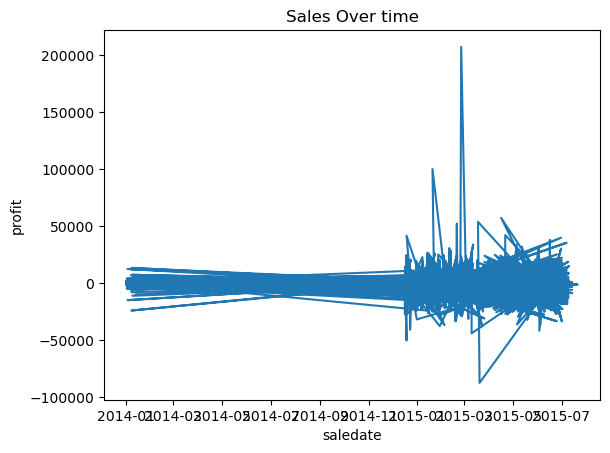

In [47]:
plt.plot(df['saledate'], df['profit'])
plt.title('Sales Over time')
plt.xlabel('saledate')
plt.ylabel('profit')
plt.show()

In [ ]:
s